# CDIs reproduction based on Wong et al. 2022

Synthetic correlated diffusion imaging CDIs pipeline, applied to the public PROSTATEx (https://wiki.cancerimagingarchive.net/display/Public/SPIE-AAPM-NCI+PROSTATEx+Challenges) training cohort. Masks from repository of https://github.com/rcuocolo/PROSTATEx_masks

## Configuration, importing libraries

In [ ]:
import sys
sys.path.insert(0, r'C:\Users\jryma\Studia\PW\cds')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src import (
    config, data_io, cdis, tissue_sampling as ts,
    analysis, visualization as viz, run_analysis as ra,
)

import warnings; warnings.filterwarnings('ignore')

print(f'Project root : {config.PROJECT_ROOT}')
print(f'Masks root   : {config.MASKS_ROOT}')
print(f'Output dir   : {config.OUT_DIR}')
print()
print('CDIs parameters:')
print(f'  Native b-values    = {config.B_NATIVE}')
print(f'  Synthetic b-values = {config.B_SYNTH}')
print(f'  Mixing in-plane σ  = {config.SIGMA_INPLANE_MM} mm')

Project root : /mnt/c/Users/jryma/Studia/PW/cds
Masks root   : /mnt/c/Users/jryma/Studia/PW/cds/PROSTATEx_masks/Files
Output dir   : /mnt/c/Users/jryma/Studia/PW/cds/src/outputs

CDIs parameters:
  Native b-values    = (50, 400, 800)
  Synthetic b-values = (1000, 2000, 3000, 4000, 5000, 6000, 7000)
  Mixing in-plane σ  = 2.0 mm


## Data description and selection

We require axial T2w, multi-b DWI with $b ∈ \{50, 400, 800\}$, T2 + ADC NIfTI, at least one lesion mask, entry in classes CSV.

In [2]:
audit_csv = config.OUT_DIR / 'patient_audit.csv'
if not audit_csv.exists():
    !python -m src.audit
audit = pd.read_csv(audit_csv)
complete = audit[audit['complete']].copy()
print(f'Total patients      : {len(audit)}')
print(f'Complete            : {len(complete)}')
for k in ['has_DWI', 'DWI_has_50_400_800', 'has_T2_nifti', 'has_ADC_nifti',
          'has_prostate_mask']:
    print(f'  {k:22s}: {int(audit[k].sum())}')
print(f'  has_any_lesion_mask   : {int((audit["n_lesion_masks_T2"] > 0).sum())}')
complete[['pid', 'DWI_desc', 'DWI_bvals', 'n_lesion_masks_T2']].head(8)

Total patients      : 219
Complete            : 129
  has_DWI               : 145
  DWI_has_50_400_800    : 140
  has_T2_nifti          : 204
  has_ADC_nifti         : 195
  has_prostate_mask     : 204
  has_any_lesion_mask   : 200


,pid,DWI_desc,DWI_bvals,n_lesion_masks_T2
0,ProstateX-0000,ep2d_diff_tra_DYNDIST,"50,400,800",1
1,ProstateX-0001,ep2d_diff_tra_DYNDIST_MIX,"50,400,800",1
2,ProstateX-0002,ep2d_diff_tra_DYNDIST,"50,400,800",2
4,ProstateX-0004,ep2d_diff_tra_DYNDIST_MIX,"50,400,800",1
5,ProstateX-0005,ep2d_diff_tra_DYNDIST_MIX,"50,400,800",2
6,ProstateX-0006,ep2d_diff_tra_DYNDIST,"50,400,800",1
7,ProstateX-0007,ep2d_diff_tra_DYNDIST,"50,400,800",1
8,ProstateX-0008,ep2d_diff_tra_DYNDIST,"50,400,800",1


## Single patient example

Picking example patient with at least one csPCa lesion. Function `load_patient` reads DWI per b-value,
resamples T2w, ADC, mask onto the DWI grid, and builds spherical lesion ROIs from
the world-space findings.

In [3]:
classes = data_io.load_classes()
csig_pids = set(classes.loc[classes['is_csPCa'], 'pid'])
demo_pid = next(p for p in complete['pid'] if p in csig_pids)
print(f'Demo patient: {demo_pid}')

bundle = ra.load_patient(demo_pid, classes)
print(f'  voxel spacing  : {tuple(round(v,2) for v in bundle.voxel_spacing)} mm')
print(f'  DWI shape      : {bundle.signals[50].shape}  (Z, Y, X)')
print(f'  prostate mask  : {int(bundle.prostate_mask.sum())} voxels')
print(f'  lesions        : {len(bundle.lesion_rois)} '
      f'(cs={sum(1 for _,c in bundle.lesion_rois if c)}, '
      f'ins={sum(1 for _,c in bundle.lesion_rois if not c)})')

Demo patient: ProstateX-0000


  voxel spacing  : (2.0, 2.0, 3.0) mm
  DWI shape      : (19, 128, 84)  (Z, Y, X)
  prostate mask  : 3759 voxels
  lesions        : 1 (cs=1, ins=0)


Visualisation of the raw inputs (DWI per b-value)

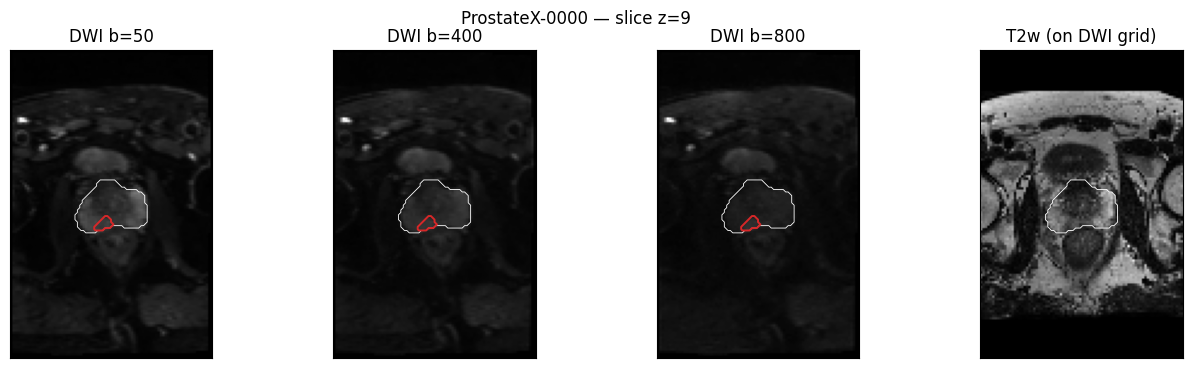

In [4]:
z = viz._pick_lesion_slice(bundle.prostate_mask, bundle.lesion_rois)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, b in zip(axes[:3], sorted(bundle.signals)):
    ax.imshow(bundle.signals[b][z], cmap='gray')
    ax.set_title(f'DWI b={b}')
    ax.contour(bundle.prostate_mask[z] > 0, levels=[0.5], colors='white', linewidths=0.6)
    for m, is_cs in bundle.lesion_rois:
        ax.contour(m[z] > 0, levels=[0.5],
                   colors=[config.TISSUE_COLORS['csPCa' if is_cs else 'insPCa']],
                   linewidths=1.4)
    ax.set_xticks([]); ax.set_yticks([])
axes[3].imshow(bundle.t2w[z], cmap='gray')
axes[3].set_title('T2w (on DWI grid)')
axes[3].contour(bundle.prostate_mask[z] > 0, levels=[0.5], colors='white', linewidths=0.6)
axes[3].set_xticks([]); axes[3].set_yticks([])
fig.suptitle(f'{demo_pid} — slice z={z}')
plt.show()

## CDIs computation

From Wong et al. 2022, equations (3)–(5):

In [5]:
res = cdis.compute_cdis(bundle.signals, bundle.prostate_mask, bundle.voxel_spacing)
pm = bundle.prostate_mask > 0
print(f'Â (LSQ ADC) in gland  : median = {np.median(res.adc[pm])*1e3:.3f} ×10⁻³ mm²/s')
print(f'log(CDIs)  in gland   : median = {np.median(res.log_cdis[pm]):.3f}  (should be ~0)')
print(f'Z calibration         : {res.z_calibration:.3e}')
print('ρ coefficients        :', dict(res.rho))

Â (LSQ ADC) in gland  : median = 1.444 ×10⁻³ mm²/s
log(CDIs)  in gland   : median = 0.000  (should be ~0)
Z calibration         : 3.330e-03
ρ coefficients        : {50: 1.0, 1000: 1.0, 2000: 1.0, 3000: 1.0, 4000: 1.0, 5000: 1.0, 6000: 1.0, 7000: 1.0}


### What the synthesizer produced

Comparsion of native S(b=800) with synthesised $\hat S(b=2000)$ and $\hat S(b=4000)$
to see how higher b looks.

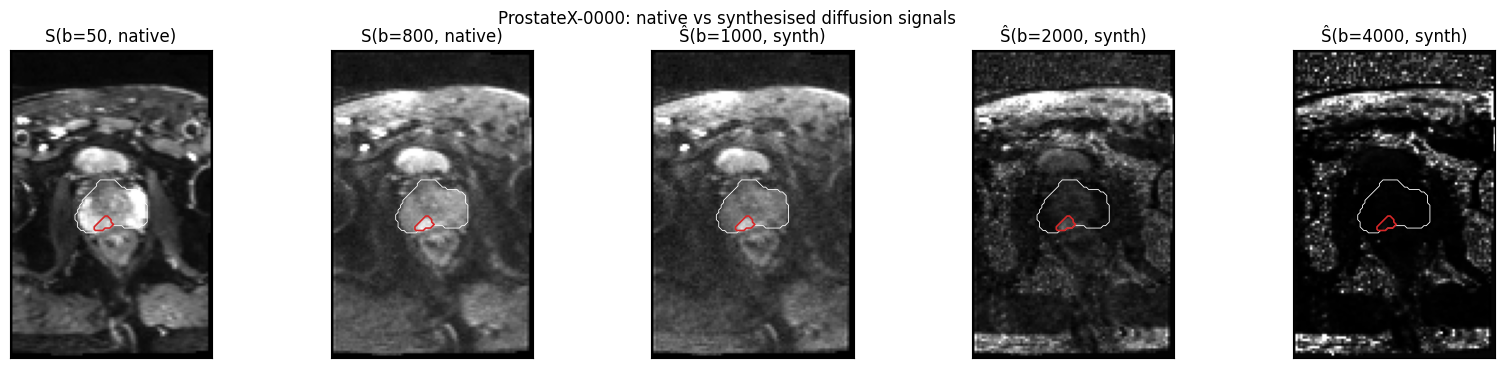

In [6]:
synth = cdis.synthesize(bundle.signals[50], res.adc, [1000, 2000, 4000, 7000])
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
panels = [('S(b=50, native)',  bundle.signals[50]),
          ('S(b=800, native)', bundle.signals[800]),
          ('Ŝ(b=1000, synth)', synth[1000]),
          ('Ŝ(b=2000, synth)', synth[2000]),
          ('Ŝ(b=4000, synth)', synth[4000])]
for ax, (name, vol) in zip(axes, panels):
    ax.imshow(vol[z], cmap='gray', vmax=np.percentile(vol[z], 99))
    ax.contour(bundle.prostate_mask[z] > 0, levels=[0.5], colors='white', linewidths=0.6)
    for m, is_cs in bundle.lesion_rois:
        ax.contour(m[z] > 0, levels=[0.5],
                   colors=[config.TISSUE_COLORS['csPCa' if is_cs else 'insPCa']],
                   linewidths=1.2)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'{demo_pid}: native vs synthesised diffusion signals')
plt.show()

## Sanity check on one patient

Tissue summaries for this single patient.

In [7]:
h_idx = ts.pick_healthy_indices(bundle.prostate_mask, bundle.lesion_rois)
demo_samples = {
    'T2w':        ts.sample_modality(bundle.t2w,    h_idx, bundle.lesion_rois),
    'ADC':        ts.sample_modality(bundle.adc,    h_idx, bundle.lesion_rois),
    'log(CDIs)':  ts.sample_modality(res.log_cdis,  h_idx, bundle.lesion_rois),
}
rows = []
for mod, samp in demo_samples.items():
    for cls in ('healthy', 'insPCa', 'csPCa'):
        v = np.asarray(samp[cls], dtype=float)
        if len(v) == 0: continue
        rows.append({'modality': mod, 'tissue': cls, 'n': len(v),
                     'median': float(np.median(v)),
                     'p25': float(np.percentile(v, 25)),
                     'p75': float(np.percentile(v, 75))})
pd.DataFrame(rows)

,modality,tissue,n,median,p25,p75
0,T2w,healthy,30,191.000000,111.250000,301.500000
1,T2w,csPCa,56,217.000000,177.750000,250.500000
2,ADC,healthy,30,1383.500000,1160.000000,1583.750000
3,ADC,csPCa,56,1177.000000,1051.250000,1274.000000
4,log(CDIs),healthy,30,0.756773,-4.729527,4.142469
5,log(CDIs),csPCa,56,6.722097,4.417036,9.264596


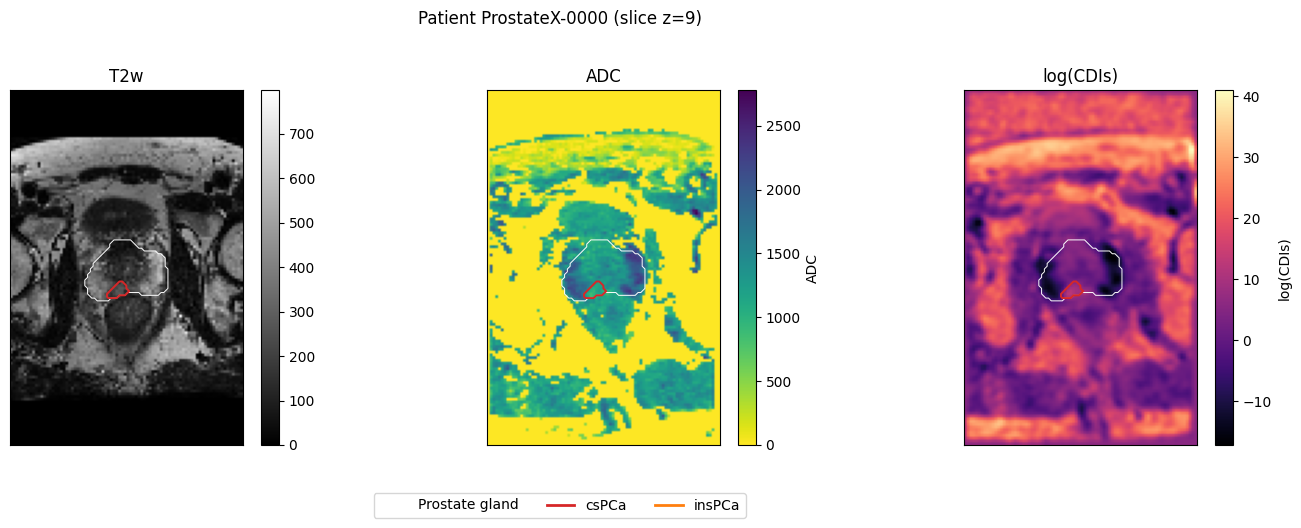

In [8]:
fig = viz.plot_patient_overlays(
    bundle.t2w, bundle.adc, res.cdis,
    bundle.prostate_mask, bundle.lesion_rois,
    title=f'Patient {demo_pid}',
)
plt.show()

## Multi-patient gallery (Fig. 3 reproduction)

Representative patients with diverse lesion types. Lesion zone is derived from intersection with PZ / TZ masks (Cuocolo).

In [ ]:
def find_by_zone(target_zone, *, csig_only=True, mixed=False, ins_only=False):
    for pid in complete['pid']:
        b = ra.load_patient(pid, classes)
        if b is None: continue
        cs_zones, ins_zones = set(), set()
        for m, is_cs in b.lesion_rois:
            z = ts.assign_zone(m, b.pz_mask, b.tz_mask)
            (cs_zones if is_cs else ins_zones).add(z)
        if ins_only and (not cs_zones and ins_zones): return pid
        if mixed    and (cs_zones and ins_zones):     return pid
        if target_zone is not None and target_zone in cs_zones: return pid
    return None

gallery_specs = [
    ('csPCa in PZ',        find_by_zone('PZ')),
    ('csPCa in TZ',        find_by_zone('TZ')),
    # ('csPCa in AS',        find_by_zone('AS')),
    ('csPCa + insPCa',     find_by_zone(None, mixed=True)),
    ('insPCa only',        find_by_zone(None, ins_only=True)),
]
gallery_specs = [(t, p) for (t, p) in gallery_specs if p is not None]
for t, p in gallery_specs:
    print(f'  {t:20s}: {p}')

  csPCa in PZ         : ProstateX-0000
  csPCa in TZ         : ProstateX-0014
  csPCa + insPCa      : ProstateX-0002
  insPCa only         : ProstateX-0001


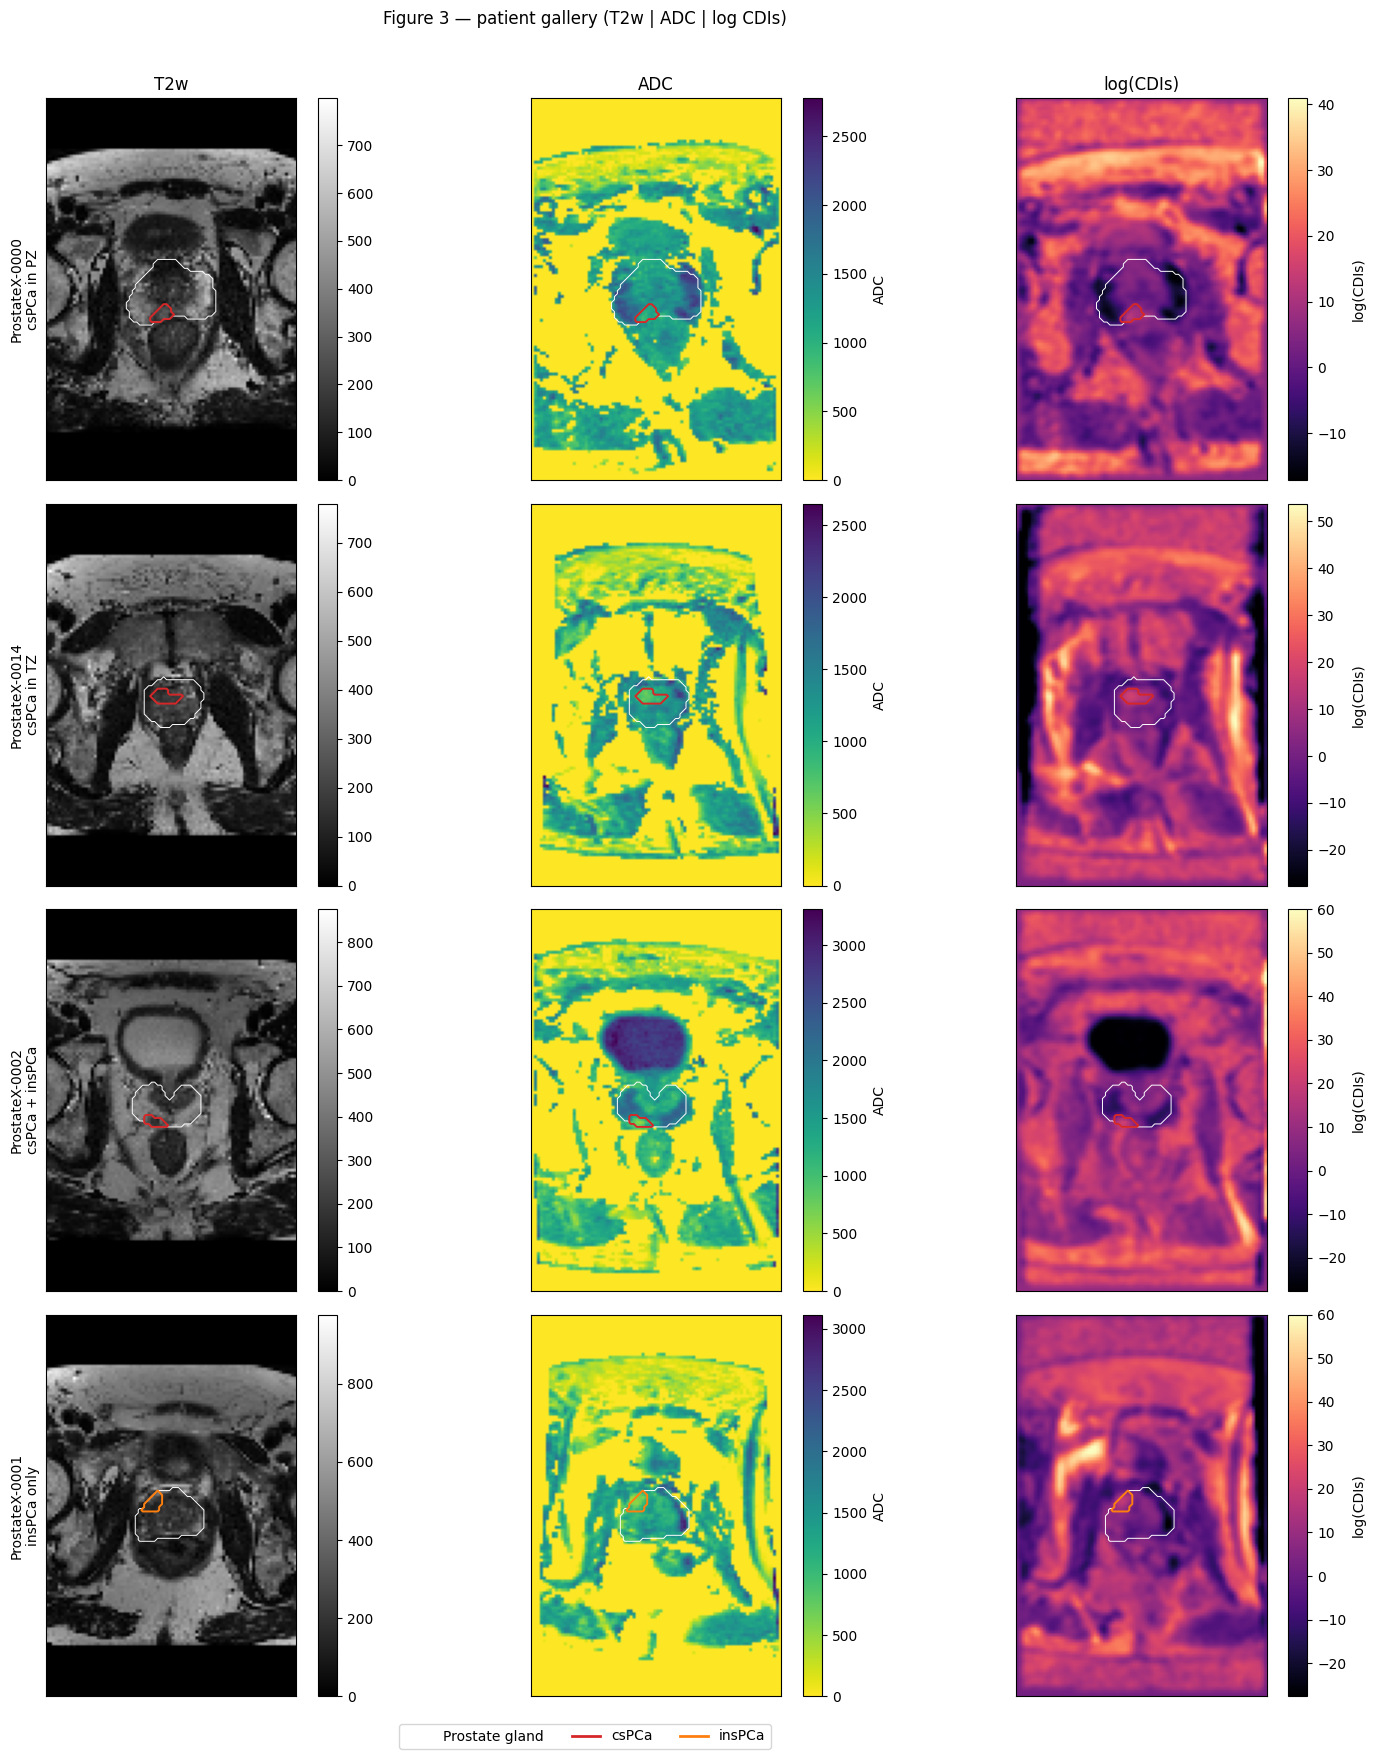

In [10]:
gallery_data = []
for tag, pid in gallery_specs:
    b = ra.load_patient(pid, classes)
    if b is None: continue
    r = cdis.compute_cdis(b.signals, b.prostate_mask, b.voxel_spacing)
    gallery_data.append({
        'pid': pid, 'tag': tag,
        't2w': b.t2w, 'adc': b.adc, 'cdis': r.cdis,
        'prostate_mask': b.prostate_mask,
        'lesion_rois': b.lesion_rois,
    })
fig = viz.plot_patient_grid(gallery_data,
                            title='Figure 3 — patient gallery (T2w | ADC | log CDIs)')
plt.show()

## 7. Cohort of 129 patients with complete data of DWI b=50, 400, 800

In [11]:
import time
MAX_PATIENTS = None
pids = complete['pid'].tolist() if MAX_PATIENTS is None else complete['pid'].head(MAX_PATIENTS).tolist()

bundles = []
t0 = time.time()
for i, pid in enumerate(pids, 1):
    try:
        b = ra.load_patient(pid, classes)
        if b is not None: bundles.append(b)
        if i % 10 == 0:
            print(f'  [{i:3d}/{len(pids)}] loaded {len(bundles)} (elapsed {time.time()-t0:.0f}s)')
    except Exception as e:
        print(f'  {pid}: ERROR {e}')
print(f'Total loaded: {len(bundles)} patients in {time.time()-t0:.0f}s')

  [ 10/129] loaded 10 (elapsed 43s)


  [ 20/129] loaded 20 (elapsed 88s)


  [ 30/129] loaded 30 (elapsed 130s)


  [ 40/129] loaded 40 (elapsed 175s)


  [ 50/129] loaded 50 (elapsed 218s)


...

  [ 90/129] loaded 90 (elapsed 397s)


  [100/129] loaded 100 (elapsed 444s)


  [110/129] loaded 110 (elapsed 489s)


  [120/129] loaded 120 (elapsed 532s)


Total loaded: 129 patients in 571s


In [12]:
all_samples = [ra.sample_patient(b)['samples'] for b in bundles]
pools = [
    ts.pool_modality('CDIs', [s['CDIs'] for s in all_samples]),
    ts.pool_modality('T2w',  [s['T2w']  for s in all_samples if 'T2w' in s]),
    ts.pool_modality('ADC',  [s['ADC']  for s in all_samples if 'ADC' in s]),
]
for p in pools:
    print(f'  {p.name:6s}: healthy={len(p.healthy):6d}  insPCa={len(p.insPCa):5d}  csPCa={len(p.csPCa):5d}')

  CDIs  : healthy=  3870  insPCa=14777  csPCa= 5144
  T2w   : healthy=  3870  insPCa=14777  csPCa= 5144
  ADC   : healthy=  3870  insPCa=14777  csPCa= 5144


## 8. Histograms (Fig. 1)

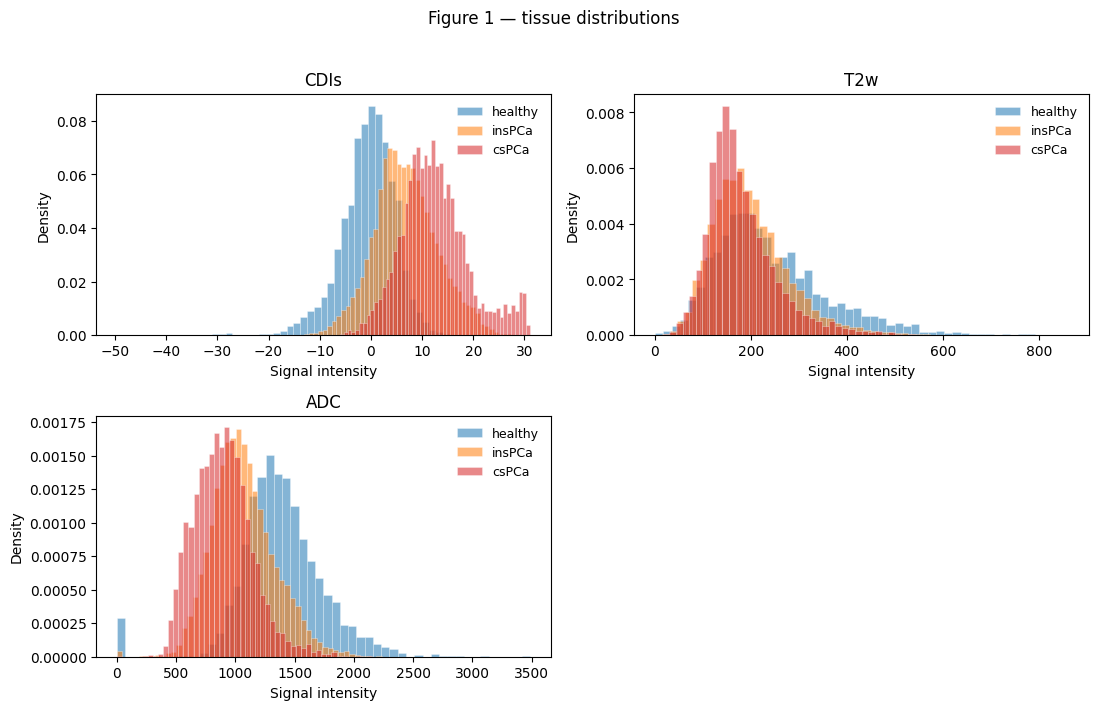

In [13]:
fig = viz.plot_histograms(pools, title='Figure 1 — tissue distributions')
plt.show()

## 9. ROC + AUC (Fig. 2)

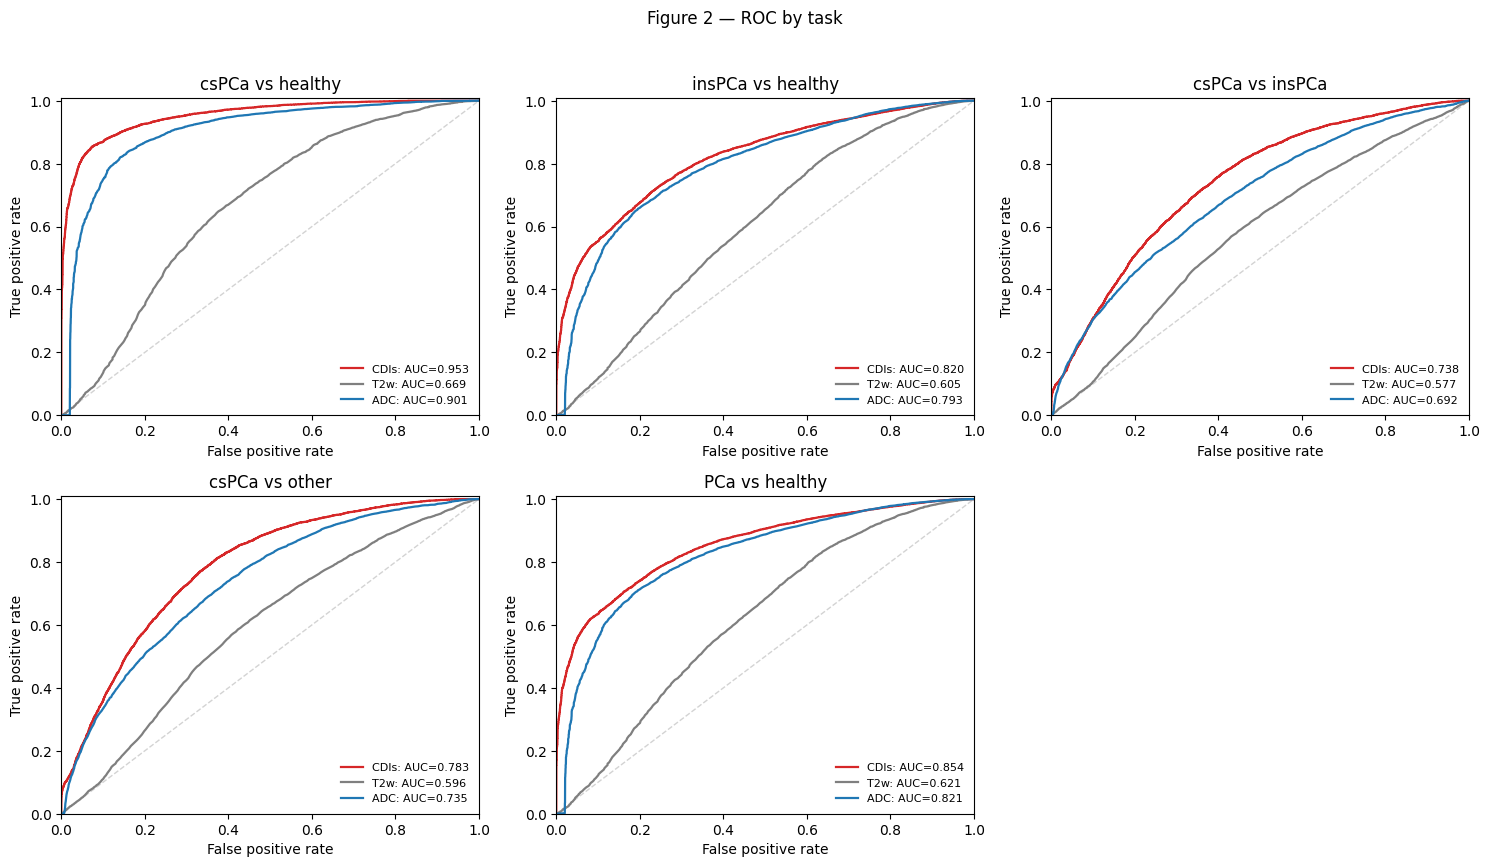

AUC summary:
             task modality      auc  n_pos  n_neg       se
 csPCa vs healthy     CDIs 0.952874   5144   3870 0.002187
 csPCa vs healthy      T2w 0.668730   5144   3870 0.005613
 csPCa vs healthy      ADC 0.901106   5144   3870 0.003207
insPCa vs healthy     CDIs 0.819937  14777   3870 0.003213
insPCa vs healthy      T2w 0.604621  14777   3870 0.004858
insPCa vs healthy      ADC 0.793097  14777   3870 0.003490
  csPCa vs insPCa     CDIs 0.738410   5144  14777 0.004320
  csPCa vs insPCa      T2w 0.576618   5144  14777 0.004719
  csPCa vs insPCa      ADC 0.691830   5144  14777 0.004511
   csPCa vs other     CDIs 0.782920   5144  18647 0.004017
   csPCa vs other      T2w 0.595735   5144  18647 0.004604
   csPCa vs other      ADC 0.735263   5144  18647 0.004268
   PCa vs healthy     CDIs 0.854264  19921   3870 0.002640
   PCa vs healthy      T2w 0.621175  19921   3870 0.004608
   PCa vs healthy      ADC 0.820987  19921   3870 0.003015


In [14]:
fig = viz.plot_roc_grid(pools, title='Figure 2 — ROC by task')
plt.show()

auc_df = viz.auc_table(pools)
print('AUC summary:')
print(auc_df.to_string(index=False))

In [15]:
# Side-by-side with Wong et al. 2022 Supplementary Table 1.
paper = {
    'csPCa vs healthy':  {'T2w': 0.642, 'ADC': 0.813, 'CDIs': 0.846},
    'csPCa vs insPCa':   {'T2w': 0.652, 'ADC': 0.694, 'CDIs': 0.853},
    'PCa vs healthy':    {'T2w': 0.703, 'ADC': 0.808, 'CDIs': 0.846},
    'csPCa vs other':    {'T2w': 0.642, 'ADC': 0.813, 'CDIs': 0.846},
}
rows = []
for task, modalities in paper.items():
    for mod, paper_auc in modalities.items():
        ours = auc_df.query('task == @task and modality == @mod')
        if not ours.empty:
            rows.append({'task': task, 'modality': mod,
                         'paper_AUC': paper_auc,
                         'our_AUC': float(ours['auc'].iloc[0]),
                         'Δ': float(ours['auc'].iloc[0]) - paper_auc})
pd.DataFrame(rows)

,task,modality,paper_AUC,our_AUC,Δ
0,csPCa vs healthy,T2w,0.642,0.668730,0.026730
1,csPCa vs healthy,ADC,0.813,0.901106,0.088106
2,csPCa vs healthy,CDIs,0.846,0.952874,0.106874
3,csPCa vs insPCa,T2w,0.652,0.576618,-0.075382
4,csPCa vs insPCa,ADC,0.694,0.691830,-0.002170
5,csPCa vs insPCa,CDIs,0.853,0.738410,-0.114590
6,PCa vs healthy,T2w,0.703,0.621175,-0.081825
7,PCa vs healthy,ADC,0.808,0.820987,0.012987
8,PCa vs healthy,CDIs,0.846,0.854264,0.008264
9,csPCa vs other,T2w,0.642,0.595735,-0.046265


## 10. CDIs — rho tuning

In [16]:
RUN_RHO_TUNING = True
MAXITER = 5
rho_t = None
if RUN_RHO_TUNING:
    rho_inputs = [{'signals': b.signals, 'prostate_mask': b.prostate_mask,
                   'voxel_spacing': b.voxel_spacing, 'lesion_rois': b.lesion_rois} for b in bundles]
    rho_t, best_auc = cdis.optimize_rho(rho_inputs, task='csPCa_vs_healthy', maxiter=MAXITER)
    print(f'Best AUC during ρ tuning: {best_auc:.4f}')
    print('ρ_t =', {b: round(v, 3) for b, v in rho_t.items()})
else:
    print('ρ tuning skipped.')

Best AUC during ρ tuning: 0.9355
ρ_t = {50: 1.019, 1000: 1.019, 2000: 1.019, 3000: 1.019, 4000: 1.019, 5000: 1.019, 6000: 1.019, 7000: 0.9}


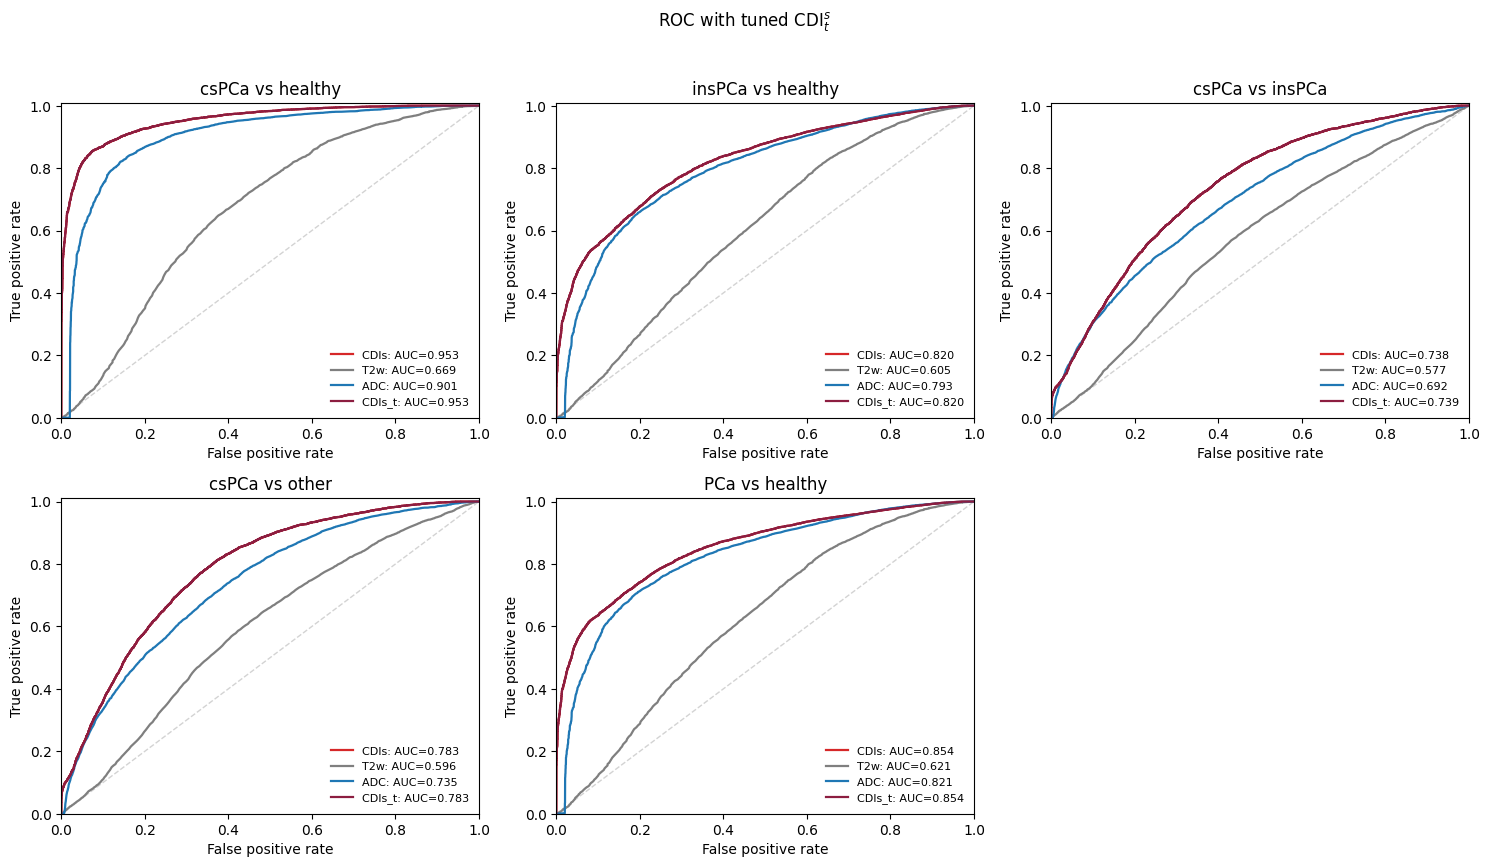

,task,modality,auc,n_pos,n_neg,se
0,csPCa vs healthy,CDIs,0.952874,5144,3870,0.002187
1,csPCa vs healthy,T2w,0.668730,5144,3870,0.005613
2,csPCa vs healthy,ADC,0.901106,5144,3870,0.003207
3,csPCa vs healthy,CDIs_t,0.953040,5144,3870,0.002183
4,insPCa vs healthy,CDIs,0.819937,14777,3870,0.003213
5,insPCa vs healthy,T2w,0.604621,14777,3870,0.004858
6,insPCa vs healthy,ADC,0.793097,14777,3870,0.003490
7,insPCa vs healthy,CDIs_t,0.820150,14777,3870,0.003211
8,csPCa vs insPCa,CDIs,0.738410,5144,14777,0.004320
9,csPCa vs insPCa,T2w,0.576618,5144,14777,0.004719


In [ ]:
if rho_t is not None:
    samples_t = []
    for b in bundles:
        res_t = cdis.compute_cdis(b.signals, b.prostate_mask, b.voxel_spacing, rho=rho_t)
        h_idx = ts.pick_healthy_indices(b.prostate_mask, b.lesion_rois)
        samples_t.append({'CDIs_t': ts.sample_modality(res_t.log_cdis, h_idx, b.lesion_rois)})
    pools_full = pools + [ts.pool_modality('CDIs_t', [s['CDIs_t'] for s in samples_t])]
    fig = viz.plot_roc_grid(pools_full, title='ROC with tuned CDIs_t')
    plt.show()
    display(viz.auc_table(pools_full))
else:
    pools_full = pools
    print('Using baseline pools (no CDIs_t).')